In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
zip_path = "/content/drive/MyDrive/ALL_dataset1.zip"

In [ ]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

In [ ]:
import os
os.listdir("/content/dataset/ALL_dataset1")

['Blood cell Cancer _ALL']

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import tensorflow as tf

# ==========================
# 1. Setup Google Colab Environment
# ==========================
# Check if GPU is available
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("GPU Device:", tf.test.gpu_device_name())

# Path to the dataset (adjust to where your data is on Google Drive)
root_input = "/content/drive/My Drive/datasets"
data_dir = "/content/dataset/ALL_dataset1/Blood cell Cancer _ALL"

if not os.path.exists(data_dir):
    print("❌ Dataset path not found. Available folders are:")
    print(os.listdir(root_input))
    raise FileNotFoundError("Please check your dataset path!")

# ==========================
# 2. Setup model saving directory
# ==========================
save_dir = "/content/drive/My Drive/ResNet50_ALL1_models"
os.makedirs(save_dir, exist_ok=True)
checkpoint_path = f"{save_dir}/ResNet50_best.keras"

# ==========================
# 3. Build DataFrame
# ==========================
classes = [c for c in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, c))]
classes = sorted(classes)

all_images, all_labels = [], []
for cls in classes:
    cls_folder = os.path.join(data_dir, cls)
    for img_file in os.listdir(cls_folder):
        if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_images.append(os.path.join(cls_folder, img_file))
            all_labels.append(cls)

df = pd.DataFrame({'filepath': all_images, 'label': all_labels})
label2idx = {cls: i for i, cls in enumerate(classes)}
df['label_idx'] = df['label'].map(label2idx)

print(f"✅ Found {len(classes)} classes: {classes}")
print(f"✅ Total images: {len(df)}")

# ==========================
# 4. Train/Val Split
# ==========================
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label_idx'], random_state=42)

# ==========================
# 5. Data Generators
# ==========================
from tensorflow.keras.preprocessing.image import ImageDataGenerator

preprocess_fn = tf.keras.applications.resnet50.preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_fn,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(224,224), class_mode='categorical',
    batch_size=32, shuffle=True
)
val_gen = val_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=(224,224), class_mode='categorical',
    batch_size=32, shuffle=False
)

# ==========================
# 6. Mixed Precision (GPU boost)
# ==========================
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# ==========================
# 7. Model: Resume if checkpoint exists
# ==========================
if os.path.exists(checkpoint_path):
    print("✅ Found checkpoint, resuming training...")
    model = tf.keras.models.load_model(checkpoint_path)
else:
    print("⚠️ No checkpoint found, building new model...")
    base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base_model.trainable = False

    x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    output = tf.keras.layers.Dense(len(classes), activation='softmax', dtype='float32')(x)

    model = tf.keras.Model(base_model.input, output)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ==========================
# 8. Callbacks
# ==========================
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path, monitor='val_accuracy',
    save_best_only=True, verbose=1
)
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# ==========================
# 9. Train with GPU
# ==========================
with tf.device("/GPU:0"):
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=30,
        callbacks=[checkpoint, early_stop],
        verbose=1
    )

# ==========================
# 10. Evaluation
# ==========================
y_pred = np.argmax(model.predict(val_gen), axis=1)
y_true = val_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.show()


Num GPUs Available: 1
GPU Device: /device:GPU:0
✅ Found 4 classes: ['Benign', 'Malignant_ Pre-B', 'Malignant_Pro-B', 'Malignant_early Pre-B']
✅ Total images: 3242
Found 2593 validated image filenames belonging to 4 classes.
Found 649 validated image filenames belonging to 4 classes.
⚠️ No checkpoint found, building new model...
Epoch 1/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 856ms/step - accuracy: 0.6307 - loss: 1.0354
Epoch 1: val_accuracy improved from -inf to 0.91217, saving model to /content/drive/My Drive/ResNet50_ALL1_models/ResNet50_best.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.6322 - loss: 1.0308 - val_accuracy: 0.9122 - val_loss: 0.2271
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 806ms/step - accuracy: 0.9015 - loss: 0.2683
Epoch 2: val_accuracy improved from 0.91217 to 0.95994, saving model to /content/drive/My Drive/ResNet50_ALL1_models/ResNet50_best.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 74s 910ms/step - accuracy: 0.9015 - loss: 0.2682 - val_accuracy: 0.9599 - val_loss: 

NameError: name 'classification_report' is not defined

21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 390ms/step

Classification Report:
                       precision    recall  f1-score   support

               Benign       0.99      0.96      0.98       103
     Malignant_ Pre-B       1.00      0.98      0.99       191
      Malignant_Pro-B       0.98      1.00      0.99       159
Malignant_early Pre-B       0.98      0.99      0.98       196

             accuracy                           0.99       649
            macro avg       0.99      0.98      0.98       649
         weighted avg       0.99      0.99      0.99       649



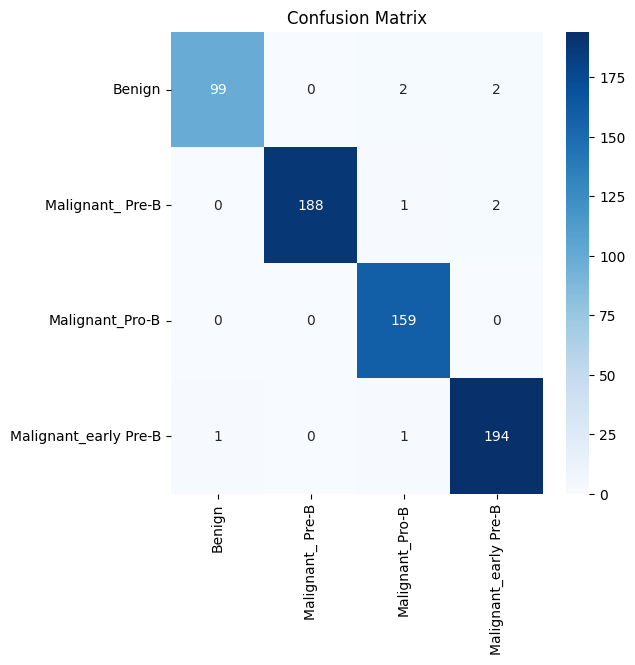

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = np.argmax(model.predict(val_gen), axis=1)
y_true = val_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.show()


In [ ]:
val_loss, val_acc = model.evaluate(val_gen)
print(f"Validation Accuracy: {val_acc:.4f}")


21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 397ms/step - accuracy: 0.9807 - loss: 0.0510
Validation Accuracy: 0.9861


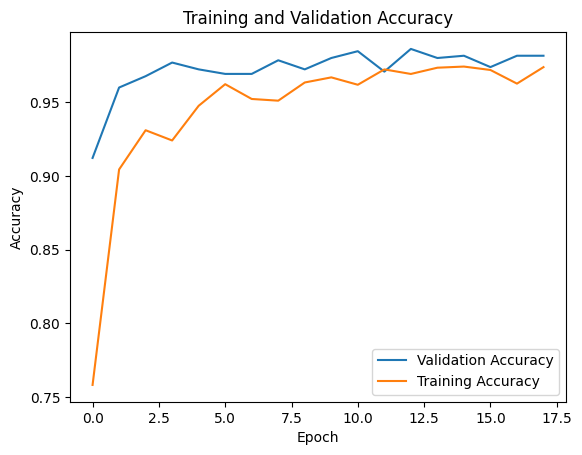

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()


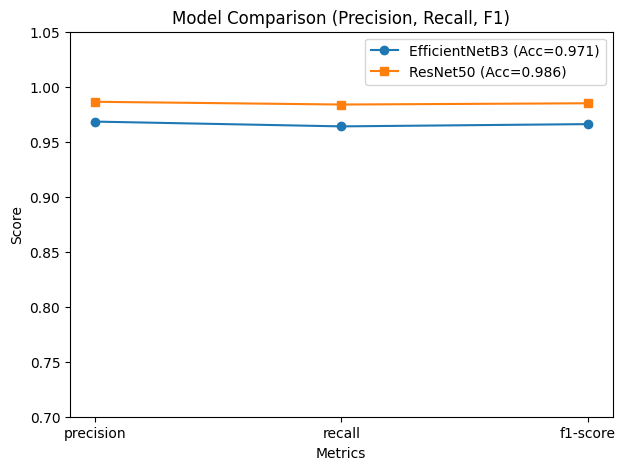

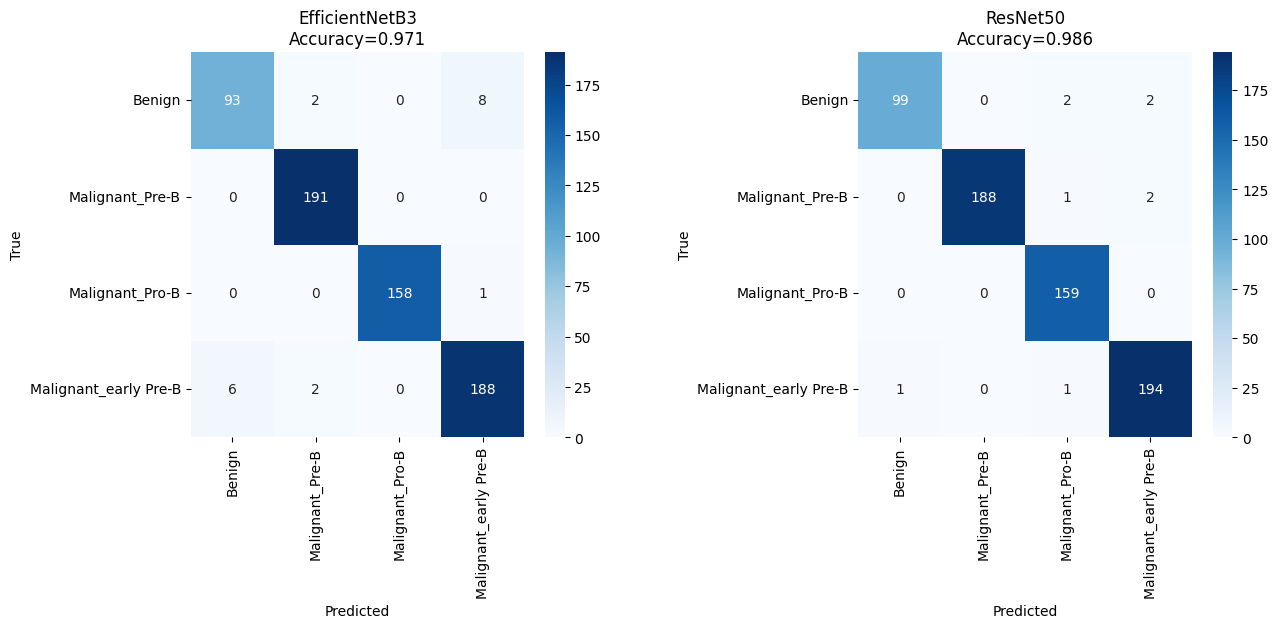

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score
import seaborn as sns

# ==== Confusion matrices ====
cm1 = np.array([
    [93, 2, 0, 8],
    [0, 191, 0, 0],
    [0, 0, 158, 1],
    [6, 2, 0, 188]
])

cm2 = np.array([
    [99, 0, 2, 2],
    [0, 188, 1, 2],
    [0, 0, 159, 0],
    [1, 0, 1, 194]
])

# Class labels
labels = ["Benign", "Malignant_Pre-B", "Malignant_Pro-B", "Malignant_early Pre-B"]

# Function to compute precision, recall, f1 from confusion matrix
def get_metrics(cm):
    y_true = []
    y_pred = []
    for i in range(len(cm)):
        for j in range(len(cm)):
            y_true += [i]*cm[i][j]
            y_pred += [j]*cm[i][j]
    report = classification_report(y_true, y_pred, target_names=labels, output_dict=True, zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    return accuracy, report

# Get metrics
acc1, report1 = get_metrics(cm1)
acc2, report2 = get_metrics(cm2)

# Extract macro averages
metrics = ["precision", "recall", "f1-score"]
values1 = [report1["macro avg"][m] for m in metrics]
values2 = [report2["macro avg"][m] for m in metrics]

# ==== Line Graph Comparison (like training/validation curves) ====
plt.figure(figsize=(7,5))

plt.plot(metrics, values1, marker="o", label=f"EfficientNetB3 (Acc={acc1:.3f})")
plt.plot(metrics, values2, marker="s", label=f"ResNet50 (Acc={acc2:.3f})")

plt.ylim(0.7, 1.05)
plt.ylabel("Score")
plt.xlabel("Metrics")
plt.title("Model Comparison (Precision, Recall, F1)")
plt.legend()
plt.show()

# ==== Side-by-side Confusion Matrices with gap ====
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title(f"EfficientNetB3\nAccuracy={acc1:.3f}")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm2, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title(f"ResNet50\nAccuracy={acc2:.3f}")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.subplots_adjust(wspace=0.6)
plt.show()
